In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Машинное обучение
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

Какие персонажи составляют топ-5 по количеству реплик?

Кто с кем разговаривает и с какой частотой? (используйте heatmap)

Какая локация - самая популярная? (где чаще всего происходят действия)

In [4]:
charactersDataset=pd.read_csv("/content/simpsons_characters.xls")
episodesDataset=pd.read_csv("/content/simpsons_episodes.xls")
locationsDataset=pd.read_csv("/content/simpsons_locations.xls")
scriptDataset=pd.read_csv("/content/simpsons_script_lines.csv",on_bad_lines="skip")

In [5]:
charactersDataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6722 entries, 0 to 6721
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               6722 non-null   int64 
 1   name             6722 non-null   object
 2   normalized_name  6722 non-null   object
 3   gender           323 non-null    object
dtypes: int64(1), object(3)
memory usage: 210.2+ KB


In [6]:
charactersDataset.head()

,id,name,normalized_name,gender
0,7,Children,children,NaN
1,12,Mechanical Santa,mechanical santa,NaN
2,13,Tattoo Man,tattoo man,NaN
3,16,DOCTOR ZITSOFSKY,doctor zitsofsky,NaN
4,20,Students,students,NaN


In [7]:
episodesDataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      600 non-null    int64  
 1   image_url               596 non-null    object 
 2   imdb_rating             597 non-null    float64
 3   imdb_votes              597 non-null    float64
 4   number_in_season        600 non-null    int64  
 5   number_in_series        600 non-null    int64  
 6   original_air_date       600 non-null    object 
 7   original_air_year       600 non-null    int64  
 8   production_code         600 non-null    object 
 9   season                  600 non-null    int64  
 10  title                   600 non-null    object 
 11  us_viewers_in_millions  594 non-null    float64
 12  video_url               596 non-null    object 
 13  views                   596 non-null    float64
dtypes: float64(4), int64(5), object(5)
memory 

In [8]:
locationsDataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               4459 non-null   int64 
 1   name             4459 non-null   object
 2   normalized_name  4459 non-null   object
dtypes: int64(1), object(2)
memory usage: 104.6+ KB


In [9]:
scriptDataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50765 entries, 0 to 50764
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  50765 non-null  int64  
 1   episode_id          50765 non-null  int64  
 2   number              50765 non-null  int64  
 3   raw_text            50765 non-null  object 
 4   timestamp_in_ms     50765 non-null  int64  
 5   speaking_line       50765 non-null  bool   
 6   character_id        45131 non-null  float64
 7   location_id         50577 non-null  float64
 8   raw_character_text  45131 non-null  object 
 9   raw_location_text   50577 non-null  object 
 10  spoken_words        42868 non-null  object 
 11  normalized_text     42866 non-null  object 
 12  word_count          42868 non-null  object 
dtypes: bool(1), float64(2), int64(4), object(6)
memory usage: 4.7+ MB


In [10]:
scriptDataset.head()

,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31
1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3
2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22
3,9552,32,212,Lisa Simpson: That life is worth living.,864000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,That life is worth living.,that life is worth living,5
4,9553,32,213,Edna Krabappel-Flanders: The polls will be ope...,864000,True,40.0,3.0,Edna Krabappel-Flanders,Springfield Elementary School,The polls will be open from now until the end ...,the polls will be open from now until the end ...,33


In [15]:
scriptDataset["raw_character_text"].value_counts().index[:5]

Index(['Homer Simpson', 'Bart Simpson', 'Marge Simpson', 'Lisa Simpson',
       'C. Montgomery Burns'],
      dtype='object', name='raw_character_text')

In [34]:
def drawTopChars(charsNum=5):
  topCharsNames=scriptDataset["raw_character_text"].value_counts().index[:charsNum]
  topCharsValues=scriptDataset["raw_character_text"].value_counts().tolist()[:charsNum]

  plt.figure(figsize=(8, 8))
  plt.pie(topCharsValues, labels=topCharsNames)
  plt.show()

In [ ]:
drawTopChars()

In [46]:
def displayCharsDialogue(charsNum=5):
  topCharacters=scriptDataset["raw_character_text"].value_counts().index[:charsNum]

  filtered=scriptDataset[np.where(scriptDataset.raw_character_text.isin(topCharacters),True,False)]


  dialogue = {"char1":filtered.raw_character_text[:-1].values,"char2":filtered.raw_character_text[1:].values}
  dialogue = pd.DataFrame.from_dict(dialogue)
  dialogue = dialogue[np.where(dialogue.char1!= dialogue.char2,True,False)]

  dialogue = pd.get_dummies(dialogue.char2).groupby(dialogue.char1).apply(sum)

  fig, ax = plt.subplots(figsize=(9,7))
  im=ax.imshow(dialogue.values, cmap="viridis", aspect="auto")

  ax.set_xticks(np.arange(len(dialogue.columns)))
  ax.set_yticks(np.arange(len(dialogue.index)))
  ax.set_xticklabels(dialogue.columns,rotation=45,ha="right")
  ax.set_yticklabels(dialogue.index)

  for i in range(len(dialogue.index)):
    for j in range(len(dialogue.columns)):
      text=ax.text(j,i,int(dialogue.values[i,j]), ha="center", va="center",color="w")

  plt.colorbar(im,ax=ax)

  plt.show()

/tmp/ipykernel_25740/2920363534.py:11: FutureWarning: The provided callable <built-in function sum> is currently using np.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.sum instead.
  dialogue = pd.get_dummies(dialogue.char2).groupby(dialogue.char1).apply(sum)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


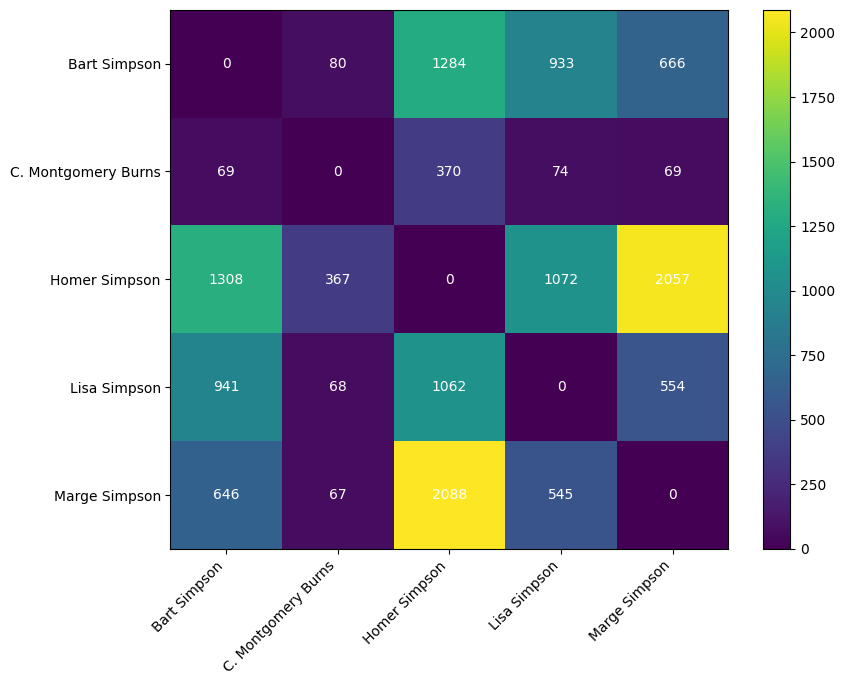

In [47]:
displayCharsDialogue()

In [59]:
def drawTopLocs(locNum=5):
  topLocNames=scriptDataset["raw_location_text"].value_counts().index[:locNum]
  topLocValues=scriptDataset["raw_location_text"].value_counts().tolist()[:locNum]

  plt.figure(figsize=(8, 8))
  plt.barh(topLocNames, topLocValues,color="red")
  plt.show()

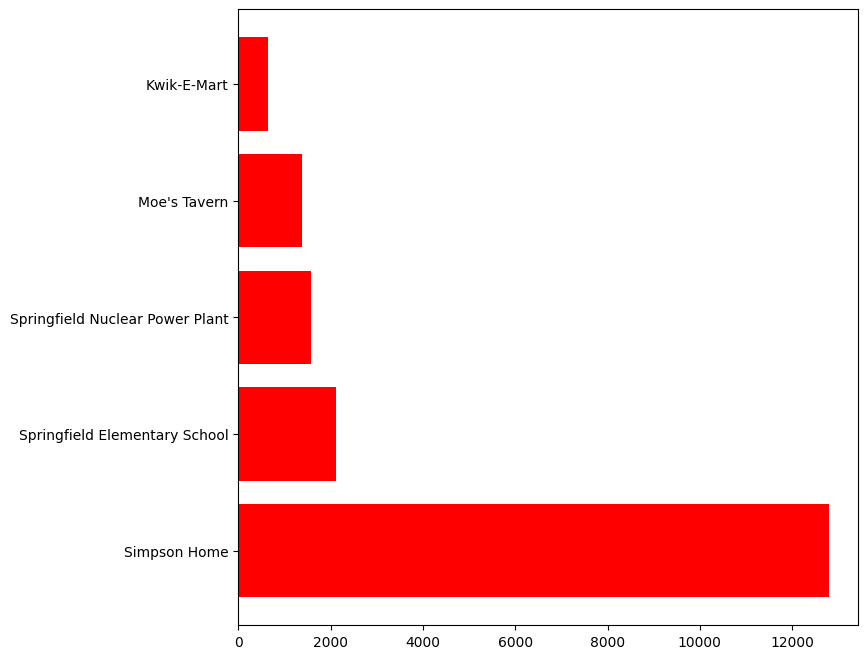

In [60]:
drawTopLocs(5)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [63]:
df=pd.read_csv("/content/data.csv")
df.columns = df.columns.str.strip()
df.isnull().sum()

,0
Price,0
Apartment type,0
Metro station,0
Minutes to metro,0
Region,0
Number of rooms,0
Area,0
Living area,0
Kitchen area,0
Floor,0


In [64]:
df.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [66]:
df["Minutes to metro"].value_counts()

,count
Minutes to metro,
13.0,2412
19.0,1800
5.0,1732
9.0,1601
11.0,1486
12.0,1484
8.0,1385
7.0,1352
14.0,1226


In [67]:
bins=[0,5,10,20,float("inf")]

labels=["У дома","В шаговой дистанции","Среднее","Далеко"]

df['Minutes to metro']=pd.cut(df["Minutes to metro"],bins=bins,labels=labels)
df=df.rename(columns={"Minutes to metro":"Metro distance"})

In [68]:
df.head()

,Price,Apartment type,Metro station,Metro distance,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,В шаговой дистанции,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,У дома,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,Среднее,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,В шаговой дистанции,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,В шаговой дистанции,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [70]:
pd.set_option('display.max_rows',None)

In [ ]:
df["Metro station"].value_counts()

In [73]:
df["Metro station"] = df["Metro station"].str.lower().str.strip()

In [75]:
df.describe()

,Price,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,2.267600e+04,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000
mean,3.612132e+07,2.043129,71.966827,38.517953,12.594082,9.190466,16.556095
std,8.282561e+07,1.523586,68.368608,38.124278,7.728074,7.549996,9.779297
min,1.150000e+06,0.000000,6.000000,2.000000,1.000000,1.000000,1.000000
25%,7.068116e+06,1.000000,37.400000,17.600000,8.600000,4.000000,11.000000
50%,1.134320e+07,2.000000,53.300000,28.500000,10.600000,8.000000,16.000000
75%,2.479925e+07,3.000000,77.140000,43.200000,14.500000,13.000000,20.000000
max,2.455020e+09,12.000000,1117.000000,566.800000,122.000000,92.000000,97.000000


In [78]:
df["Price"].max()

2455020000.0

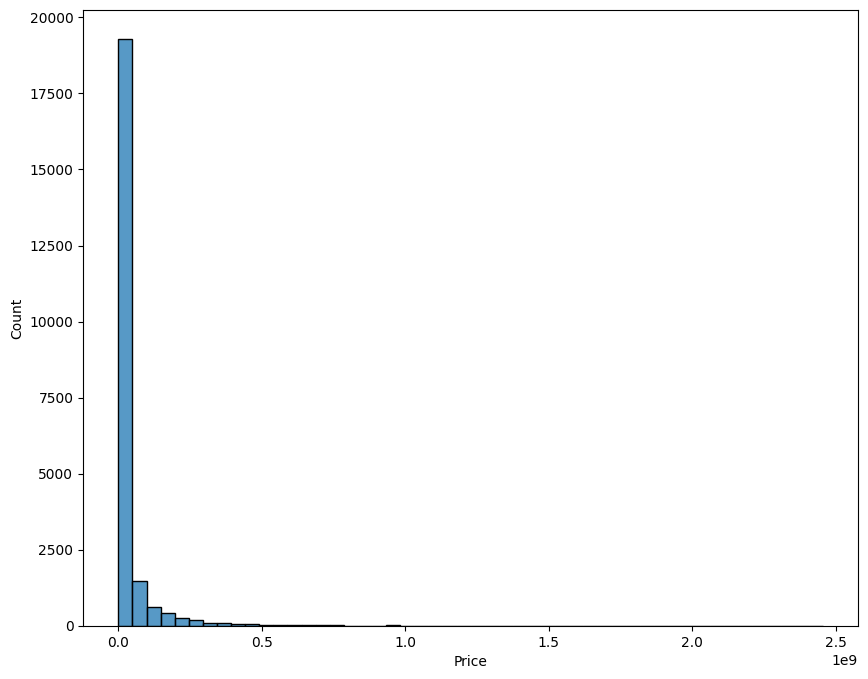

In [82]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x="Price",bins=50)
plt.show()

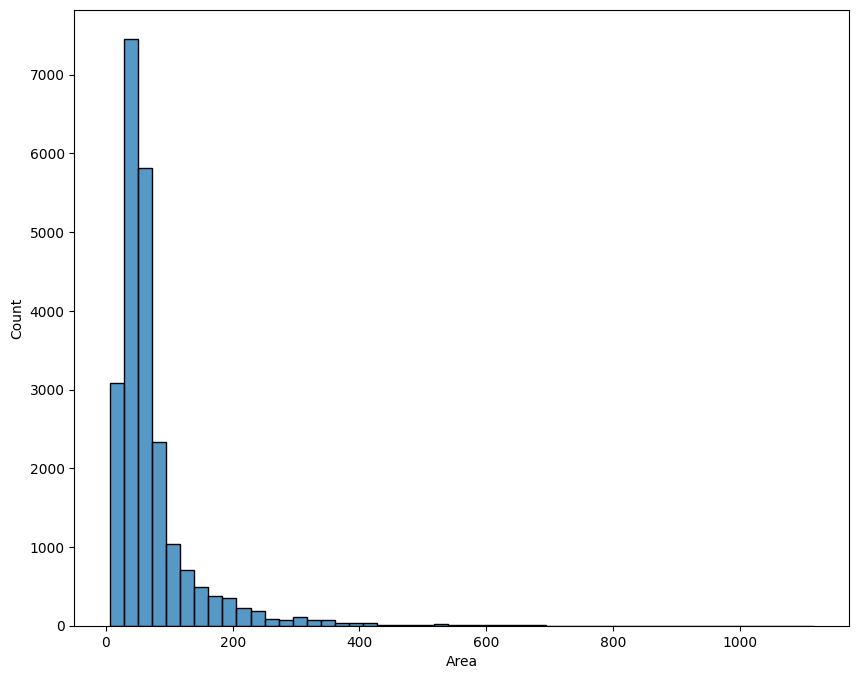

In [83]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x="Area",bins=50)
plt.show()

Text(0.5, 1.0, 'Средняя цена от количества этажей')

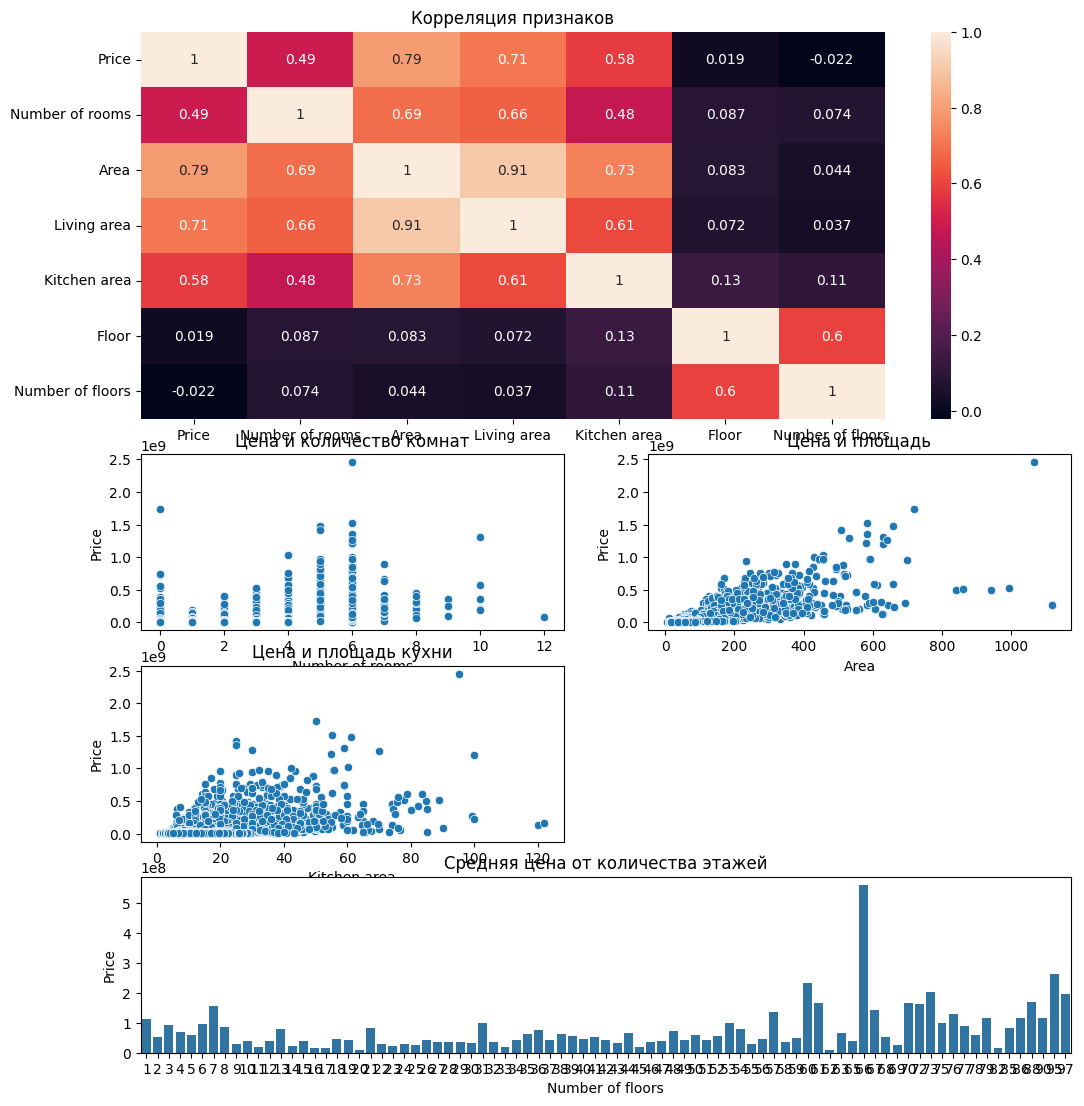

In [86]:
corr= df.select_dtypes(include=["float64","int64"]).corr()

fig = plt.figure(figsize=(12,16))

ax1=plt.subplot2grid((6,2),(0,0),rowspan=2 , colspan=2)
sns.heatmap(corr, annot=True, ax=ax1)
ax1.set_title("Корреляция признаков")

ax2 = plt.subplot2grid((6,2),(2,0))
sns.scatterplot(data=df,x="Number of rooms",y="Price",ax=ax2)
ax2.set_title("Цена и количество комнат")

ax3 = plt.subplot2grid((6,2),(2,1))
sns.scatterplot(data=df,x="Area",y="Price",ax=ax3)
ax3.set_title("Цена и площадь")

ax4 = plt.subplot2grid((6,2),(3,0))
sns.scatterplot(data=df,x="Kitchen area",y="Price",ax=ax4)
ax4.set_title("Цена и площадь кухни")

ax5 = plt.subplot2grid((6,2),(4,0),rowspan=1,colspan=2)
price = df.groupby("Number of floors").agg({'Price':'mean'})
sns.barplot(data=price,x=price.index,y=price["Price"],ax=ax5)
ax5.set_title("Средняя цена от количества этажей")

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Price             22676 non-null  float64 
 1   Apartment type    22676 non-null  object  
 2   Metro station     22676 non-null  object  
 3   Metro distance    22669 non-null  category
 4   Region            22676 non-null  object  
 5   Number of rooms   22676 non-null  float64 
 6   Area              22676 non-null  float64 
 7   Living area       22676 non-null  float64 
 8   Kitchen area      22676 non-null  float64 
 9   Floor             22676 non-null  float64 
 10  Number of floors  22676 non-null  int64   
 11  Renovation        22676 non-null  object  
dtypes: category(1), float64(6), int64(1), object(4)
memory usage: 1.9+ MB


In [88]:
cat_cols=df.select_dtypes(include=["object","category"]).columns.tolist()

In [91]:
for col in cat_cols:
 df[col]=pd.Categorical(df[col])
 df[col]=df[col].cat.codes

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             22676 non-null  float64
 1   Apartment type    22676 non-null  int8   
 2   Metro station     22676 non-null  int16  
 3   Metro distance    22676 non-null  int8   
 4   Region            22676 non-null  int8   
 5   Number of rooms   22676 non-null  float64
 6   Area              22676 non-null  float64
 7   Living area       22676 non-null  float64
 8   Kitchen area      22676 non-null  float64
 9   Floor             22676 non-null  float64
 10  Number of floors  22676 non-null  int64  
 11  Renovation        22676 non-null  int8   
dtypes: float64(6), int16(1), int64(1), int8(4)
memory usage: 1.3 MB


In [93]:
df.head()

,Price,Apartment type,Metro station,Metro distance,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,1,173,1,1,1.0,30.6,11.1,8.5,25.0,25,0
1,9000000.0,1,180,0,1,1.0,49.2,20.0,10.0,6.0,15,2
2,11090000.0,1,145,2,1,1.0,44.7,16.2,13.1,10.0,25,0
3,8300000.0,1,244,1,1,1.0,35.1,16.0,11.0,12.0,33,2
4,6450000.0,1,173,1,1,1.0,37.7,15.2,4.0,5.0,5,3


In [98]:
X = df.drop("Price",axis=1)
y = df["Price"]

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [99]:
forest=RandomForestRegressor(max_depth=10,random_state=2)
forest.fit(X_train,Y_train)
pred = forest.predict(X_test)

print(mean_squared_error(Y_test,pred)**0.5)
print(mean_absolute_percentage_error(Y_test,pred))

37417354.00900611
0.1959877190542928
